In [1]:
import requests
import pandas as pd
import datetime
import os
import json
from datetime import datetime
import traceback
import matplotlib.pyplot as plt
plt.close('all')

In [ ]:
Finaeon_API_URL = "https://api.finaeon.com/"
Finaeon_USERNAME = ""
Finaeon_PASSWORD = ""


## Functions

In [3]:
# method that outputs json file to the response directory in the relative dirctory
def writeJSONToFile(fileSuffix, jsonContents):
    now = datetime.now()
    jsonFilename = now.strftime("%Y%m%d-%H%M%S%f") + '_' + fileSuffix +'.json'
    relativeDirectory = './responses/'
    if not os.path.isdir(relativeDirectory):
        os.mkdir(relativeDirectory)
    outputfilepath = relativeDirectory + jsonFilename
    with open(outputfilepath,'w') as f:
        json.dump(jsonContents, f)

In [3]:
# Method for calling the endpoint of the api
def call_api(path, parameters):
    url = Finaeon_API_URL + path
    headers = {'Content-type': 'application/json'}
    print("calling %s" % url)
    print("request body: \r\n %s" % parameters)
    writeJSONToFile(path.strip('/') + 'Request', parameters)
    resp = requests.post(url, headers=headers, data = json.dumps(parameters))
    return resp

In [3]:
# main token generation
# token lifetime is 30 Min
def finaeon_auth(username, password):
    parameters = {'username': username, 'password': password}
    resp = call_api('/login', parameters=parameters)

    #check for unsuccessful API returns
    if resp.status_code != 200:
        raise ValueError('Finaeon API request failed with HTTP status code %s' % resp.status_code)

    json_content = resp.json()
    print("Finaeon API token recieved at %s" % str(datetime.now()))
    return json_content

In [4]:
# finaeon series accounts for all parameters and includes optional values if supplied 
def finaeon_series(token, **kwargs):
    seriesId = kwargs.get('seriesId',None)
    seriesName = kwargs.get('seriesName',None)
    splitAdjusted = kwargs.get('splitAdjusted',None)
    startDate = kwargs.get('startDate',None)
    endDate = kwargs.get('endDate',None)
    periodicity = kwargs.get('periodicity',None)
    closeOnly = kwargs.get('closeOnly',None)
    currency = kwargs.get('currency',None)
    inflationAdjusted = kwargs.get('inflationAdjusted',None)
    annualFlow = kwargs.get('annualFlow',None)
    totalReturn = kwargs.get('totalReturn',None)
    corporateActions = kwargs.get('corporateActions',None)
    metadata = kwargs.get('metadata',None)
    incFields = kwargs.get('incFields',None)
    includeAverage = kwargs.get('includeAverage',None)
    periodPercentChange = kwargs.get('periodPercentChange',None)
    parameters = {'token': token,
                  "seriesId": seriesId,
                  "seriesName": seriesName,
                  "splitAdjusted": splitAdjusted,
                  "startDate": startDate,
                  "endDate": endDate,
                  "periodicity": periodicity,
                  "closeOnly": closeOnly,
                  "currency": currency,  
                  "inflationAdjusted": inflationAdjusted,
                  "annualFlow": annualFlow,
                  "totalReturn": totalReturn,
                  "corporateActions": corporateActions,
                  "metadata": metadata,
                  "incFields": incFields,
                  "includeAverage": includeAverage,
                  "periodPercentChange": periodPercentChange
                  }

    parameters = {key:val for key, val in parameters.items() if val != None}
    r = call_api('/series', parameters=parameters)
    series_data = r.json() 
    return series_data


In [5]:
# finaeon search method
def finaeon_search(token, searchString, **kwargs):
    page = kwargs.get('page',None)
    pageSize = kwargs.get('pageSize',None)
    searchType = kwargs.get('searchType',None)
    baseFilter = kwargs.get('baseFilter',None)
    sort = kwargs.get('sort',None)
    parameters = {'token': token,
                  "page": page,
                  "pageSize": pageSize,
                  "searchString": searchString,
                  "searchType": searchType,
                  "baseFilter": baseFilter,
                  "sort": sort
                  }
    parameters = {key:val for key, val in parameters.items() if val != None}
    r = call_api('/search', parameters=parameters)
    search_data = r.json() 
    return search_data

In [5]:
# finaeon search by cik codes method
def finaeon_searchbycikcodes(token, cikCodes):
    parameters = { "token": token, "cikCodes": cikCodes }
    parameters = {key:val for key, val in parameters.items() if val != None}
    r = call_api('/searchbycikcodes', parameters)
    searchbycikcodes_data = r.json() 
    return searchbycikcodes_data


In [6]:
# finaeon fundamentals
def finaeon_fundamentals(token, seriesName, period, **kwargs):
    startDate = kwargs.get('startDate',None)
    endDate = kwargs.get('endDate',None)
    group = kwargs.get('group',None)
    parameters = {'token': token,
                  "seriesName": seriesName,
                  "period": period,
                  "startDate": startDate,
                  "endDate": endDate,
                  "group": group
                }
    parameters = {key:val for key, val in parameters.items() if val != None}
    r = call_api('/fundamentals', parameters)
    fundamentals_data = r.json() 
    return fundamentals_data


## Get Price Data

In [7]:
# Call the finaeon_auth function with credentials
authJSON = finaeon_auth(Finaeon_USERNAME, Finaeon_PASSWORD)
writeJSONToFile('Login', authJSON)

# Store Token from json response
token = authJSON['token'].strip('"')
print("Token:\r\n%s\r\n" % token)

series_info = finaeon_series(token, seriesName="IBM", startDate="01/01/2017", closeonly="true", periodicity="monthly")
series_price_data = series_info["price_data"]


In [8]:
# Pandas!

# Load main dataframe
data = pd.DataFrame(series_price_data['price_data'])
print(data)

# pivot based on series
df_columns = data.pivot(index="date", columns="series_id", values="close")
print(df_columns)


series_id    55159
date              
01/31/2017  174.52
01/31/2018  163.70
01/31/2019  134.42
01/31/2020  143.73
01/31/2021  119.11
02/28/2017  179.82
02/28/2018  155.83
02/28/2019  138.13
02/28/2021  121.02
02/29/2020  130.15
03/31/2017  174.14
03/31/2018  153.43
03/31/2019  141.10
03/31/2020  110.93
04/30/2017  160.29
04/30/2018  144.96
04/30/2019  140.27
04/30/2020  125.56
05/31/2017  152.63
05/31/2018  141.31
05/31/2019  126.99
05/31/2020  124.90
06/30/2017  153.83
06/30/2018  139.70
06/30/2019  137.90
06/30/2020  120.77
07/31/2017  144.67
07/31/2018  144.93
07/31/2019  148.24
07/31/2020  122.94
08/31/2017  143.03
08/31/2018  146.48
08/31/2019  135.53
08/31/2020  123.31
09/30/2017  145.08
09/30/2018  151.21
09/30/2019  145.42
09/30/2020  121.67
10/31/2017  154.06
10/31/2018  115.43
10/31/2019  133.73
10/31/2020  111.66
11/30/2017  153.97
11/30/2018  124.27
11/30/2019  134.45
11/30/2020  123.52
12/31/2017  153.42
12/31/2018  113.67
12/31/2019  134.04
12/31/2020  125.88


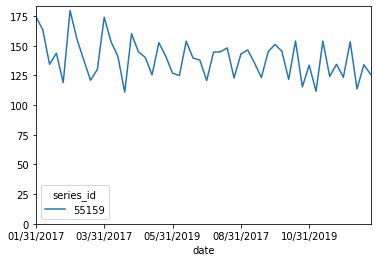

In [9]:

ax = df_columns.plot()
ax.set_ylim(ymin=0)
plt.show()


## Finaeon Search and looping

In [10]:

# Call the finaeon_auth function with credentials
authJSON = finaeon_auth(Finaeon_USERNAME, Finaeon_PASSWORD)
writeJSONToFile('Login', authJSON)

# Store Token from json response
token = authJSON['token'].strip('"')
print("Token:\r\n%s\r\n" % token)

# search API call
search_info = finaeon_search(token, searchString="General Motors", searchType="name", baseFilter="contains", sort="pop", page="3", pageSize="10")

# print results
print(search_info["search_results"])


[{'series_id': 2175, 'country_name': 'UNITED STATES', 'iso': 'USA', 'currency': 'USD', 'series': 'Sector Indices - Consumer Discretionary', 'gfd_sector': 'Equity', 'start_date': '1912-06-30T00:00:00', 'end_date': '1996-07-02T00:00:00', 'symbol': 'SPAUXGMW', 'description': 'S&P Automobiles excluding General Motors', 'periodicity': 'Monthly From Jun 1912 To Jan 1918<BR>Weekly From Jan 1918 To Jul 1996<BR>', 'metadata': "The most extensive sector indices are those that have been collected by Standard and Poor's.  These are capitalization-weighted indices that were introduced in 1923 and have weekly data back to 1918.  When the Cowles Commission did their research on historical stock prices in the 1930s, they took the S&P sector indices and extended them backward on a monthly basis to 1871, or as far back as possible, using the same stocks as the S&P indices back to 1918, and all commonly-traded shares in each sector before 1918. Together, the Cowles Commission and Standard and Poor's prov

In [11]:
#use dictionary comp to build a dict
search_dict = {s["symbol"]:s for s in search_info["search_results"]}
print(search_dict)

{'SPAUXGMW': {'series_id': 2175, 'country_name': 'UNITED STATES', 'iso': 'USA', 'currency': 'USD', 'series': 'Sector Indices - Consumer Discretionary', 'gfd_sector': 'Equity', 'start_date': '1912-06-30T00:00:00', 'end_date': '1996-07-02T00:00:00', 'symbol': 'SPAUXGMW', 'description': 'S&P Automobiles excluding General Motors', 'periodicity': 'Monthly From Jun 1912 To Jan 1918<BR>Weekly From Jan 1918 To Jul 1996<BR>', 'metadata': "The most extensive sector indices are those that have been collected by Standard and Poor's.  These are capitalization-weighted indices that were introduced in 1923 and have weekly data back to 1918.  When the Cowles Commission did their research on historical stock prices in the 1930s, they took the S&P sector indices and extended them backward on a monthly basis to 1871, or as far back as possible, using the same stocks as the S&P indices back to 1918, and all commonly-traded shares in each sector before 1918. Together, the Cowles Commission and Standard and

In [12]:

# get data by keys
# looping through each key and building a new dictionary
data_dict = {k:finaeon_series(token, seriesName=k, periodicity="monthly", totalReturn="true", startDate="01/01/2020", closeOnly="true") for k in search_dict.keys()}
print(data_dict)


{'SPAUXGMW': {'data_information': [{'series_id': 55159, 'symbol': 'IBM', 'name': 'International Business Machines Corp', 'series_type': 'Securities - Current', 'units': 'National Currency', 'scale': 'Units', 'flow': 'Stock', 'adjustment': 'none', 'periodicity': 'Monthly From Aug 1911 To Dec 1931<BR>Daily From Jan 1932 To Dec 1932<BR>Monthly From Jan 1933 To Feb 1957<BR>Daily From Mar 1957 To Feb 2021<BR>', 'metadata': 'International Business Machines Corporation (IBM) is an information technology (IT) company. It operates under five segments: Global Technology Services (GTS), Global Business Services (GBS), Software, Systems and Technology, and Global Financing. GTS primarily provides IT infrastructure services and business process services. GBS primarily provides professional services and application management services. IBM’s Software segment consists primarily of middleware and operating systems software. IBM provides clients with business solutions requiring advanced computing powe

## Fundementals

In [13]:
authJSON = finaeon_auth(Finaeon_USERNAME, Finaeon_PASSWORD)
token = authJSON['token'].strip('"')

fundementals_info = finaeon_fundamentals(token, seriesName="MSFT", period="Annual", group="Balance Sheet", startDate="01/01/2010", endDate="12/31/2020")
print(fundementals_info)


{'share_information': [{'Date': '12/31/2021',
   'Ticker': 'MSFT',
   'Close': 242.01,
   'Shares Outstanding': 7560.5,
   'Market Capitalization': 1829716.605,
   'Common Stock Net': 80552.0,
   'Depreciation Depletion & Amortization': 0.0,
   'Dividends Per Share Basic': 1.99,
   'EPS - Basic, Net': 5.82,
   'EPS - Diluted, Before Non-Recurring Items': 5.76,
   'EPS - Diluted, Net': 5.76,
   'EPS Report Date': 20200722.0,
   'Extraordinary Items & Discontinued Operations': 0.0,
   'Income Before Extraordinaries & Discontinued Operations': 44281.0,
   'Preferred Stocks': 0.0,
   'Shareholders Equity': 118304.0,
   'Preferred Dividends - Accumulated & Paid': 0.0,
   'Share Equity': 0.0,
   'Stored Market Cap Value': 0.0,
   'Stored Dividend Yield': 0.0,
   'Cash Flow Per Share': 5.856887771972753},
  {'Date': '12/31/2020',
   'Ticker': 'MSFT',
   'Close': 222.42,
   'Shares Outstanding': 7560.5,
   'Market Capitalization': 1681606.41,
   'Common Stock Net': 80552.0,
   'Depreciation De